In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import gamma
import numpy as np
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 6,
    'axes.titlesize': 6,
    'axes.labelsize': 6,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 6,
    'figure.titlesize': 6,
    'figure.dpi': 200,
    'axes.linewidth': 0.7,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Arial',
    'mathtext.it': 'Arial:italic',
    'mathtext.bf': 'Arial:bold',
})

Fig. 6e

In [2]:
# Function for reading SFS file
def read_sfs_file(file):

    with open(file, "r") as f:
        f.readline()
        sfs_data = [float(prop) for prop in f.readline().strip().split()]

    return sfs_data


def get_prop(file):

    sfs_data = read_sfs_file(file)
    sfs_data = sfs_data[1:]
    total = sum(sfs_data)

    singleton_prop = sfs_data[0] / total
    doubleton_prop = sfs_data[1] / total
    tripleton_prop = sfs_data[2] / total
    other_prop = sum(sfs_data[3:]) / total

    return {
        "singleton prop": singleton_prop,
        "doubleton prop": doubleton_prop,
        "tripleton prop": tripleton_prop,
        "4+ prop": other_prop,
    }

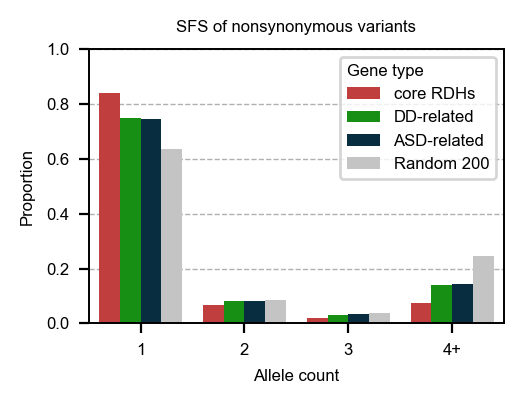

In [3]:
# Plot nonsynonymous SFSs
gene_prop_dict = {}

for gene_type in ["cRDHGs", "DD", "ASD", "R200"]:
    gene_prop_dict[gene_type] = get_prop(
        f"data/nonsyn_SFSs_DFEs/gnomadv4.nfe.nonsynonymous.folded.NS2000.{gene_type}.fs"
    )

gene_prop_df = pd.DataFrame(gene_prop_dict)
# Convert to long format
gene_prop_df = gene_prop_df.reset_index().melt(
    id_vars="index", var_name="Gene Type", value_name="Proportion"
)
gene_prop_df = gene_prop_df.rename(columns={"index": "Frequency Class"})

gene_prop_df["Frequency Class"] = gene_prop_df["Frequency Class"].map(
    {
        "singleton prop": "1",
        "doubleton prop": "2",
        "tripleton prop": "3",
        "4+ prop": "4+",
    }
)
gene_prop_df["Gene Type"] = gene_prop_df["Gene Type"].map(
    {
        "cRDHGs": "core RDHs",
        "DD": "DD-related",
        "ASD": "ASD-related",
        "R200": "Random 200",
    }
)

fig, ax = plt.subplots(figsize=(2.6, 2))

sns.barplot(
    data=gene_prop_df,
    x="Frequency Class",
    y="Proportion",
    hue="Gene Type",
    zorder=2,
    ax=ax,
    palette={
        "core RDHs": "#D62828",
        "DD-related": "#03A300",
        "ASD-related": "#003049",
        "Random 200": "#C4C4C4",
    },
)
ax.set_ylim(0, 1)
ax.set_xlabel("Allele count")
ax.set_ylabel("Proportion")
ax.set_title("SFS of nonsynonymous variants")

ax.grid(axis="y", linestyle="--", linewidth=0.5, zorder=1)
ax.legend(
    title="Gene type",
    alignment="left",
    loc="upper right",
    ncols=1,
)

plt.tight_layout()

Fig. 6f

findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


cRDHGs 0.4334735100444831 15809.420282784711 [0.00997984 0.01709559 0.04634763 0.12479703 0.31415967 0.48762024]
DD 0.4531252242644389 1097.150580935741 [0.02698743 0.0495661  0.13916489 0.35462095 0.41117263 0.01848799]
ASD 0.4842731350933014 894.7164631140483 [0.02304048 0.04716195 0.14188674 0.37875452 0.39876742 0.0103889 ]
R200 0.150816476413189 1938.8543659400807 [0.28393082 0.11781609 0.16580639 0.22207385 0.19205666 0.01831619]


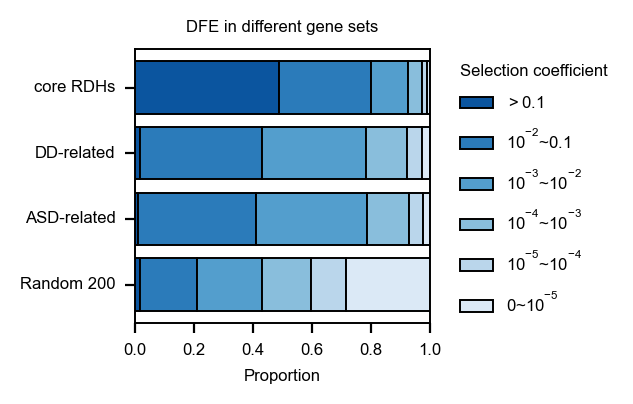

In [4]:
# Plot DFEs
gnomAD_Na = 14476
gene_name = [
    "cRDHGs",
    "DD",
    "ASD",
    "R200",
]


def get_gamma_bin(alpha, beta, bins):

    distrib = gamma(a=alpha, scale=beta)
    out = []
    for lo, hi in zip(bins[:-1], bins[1:]):
        out.append(distrib.cdf(hi) - distrib.cdf(lo))
    return np.array(out)


s_bins = np.array([0, 1e-5, 1e-4, 1e-3, 1e-2, 0.1, np.inf])
g_bins = 2 * s_bins * gnomAD_Na

gene_bin_propor = {}

for gn in gene_name:

    fit_file = f"data/nonsyn_SFSs_DFEs/gnomadv4.nfe.folded.NS2000.{gn}_1d_dfe_fits.result"
    fit_df = pd.read_csv(fit_file, sep="\t", header=None)
    fit_df.columns = ["ll", "alpha", "beta", "theta"]
    best_fit = fit_df.loc[fit_df.ll.idxmax()]

    alpha, beta, theta = best_fit["alpha"], best_fit["beta"], best_fit["theta"]
    gamma_bins = get_gamma_bin(alpha, beta, g_bins)

    gene_bin_propor[gn] = gamma_bins
    print(gn, alpha, beta, gamma_bins)

s_bin_name = [
    r"$0\textasciitilde10^{-5}$",
    r"$10^{-5}\textasciitilde10^{-4}$",
    r"$10^{-4}\textasciitilde10^{-3}$",
    r"$10^{-3}\textasciitilde10^{-2}$",
    r"$10^{-2}\textasciitilde0.1$",
    r"$>0.1$",
]

# bar plot (stacked)
x = np.arange(len(gene_name))  # the label locations
width = 0.8  # the width of the bars

fig, ax = plt.subplots(figsize=(3.2, 2))

bottom = np.zeros(len(gene_name))
colors = sns.color_palette("Blues", len(s_bin_name))
for i, s_bin in enumerate(list(reversed(s_bin_name))):
    propor = [list(reversed(gene_bin_propor[gn]))[i] for gn in gene_name]
    ax.barh(
        x,
        propor,
        height=width,
        label=s_bin,
        left=bottom,
        color=list(reversed(colors))[i],
        linewidth=0.7,
        edgecolor="black",
    )
    bottom += np.array(propor)

ax.set_xlabel("Proportion")
ax.set_yticks(x)
ax.set_yticklabels(
    ["core RDHs", "DD-related", "ASD-related", "Random 200"], rotation=0, va="center"
)
ax.legend(
    title="Selection coefficient",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False,
    alignment="left",
    labelspacing=1,
)
ax.set_xlim(0, 1)
ax.set_title(f"DFE in different gene sets")
ax.yaxis.set_inverted(True)

plt.tight_layout()